# Análisis de reseñas de `loveholidays.com`

Este notebook realiza un análisis completo de las reseñas de Trustpilot para la empresa loveholidays.com del sector Travel & Vacation. Los objetivos son:

0. Extracción y limpieza de datos
1. Análisis de sentimiento: ¿las reseñas son mayoritariamente positivas o negativas?
2. Análisis de topics: ¿qué temas tratan las reseñas?
3. Sentimiento por topic: ¿qué temas generan satisfacción o insatisfacción?
4. Comparación con competencia
5. Identificación de áreas de mejora

## 1) Librerías

En primer lugar, importo las librerías necesarias para el análisis. 

In [1]:
import re
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from textblob import TextBlob
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


He importado las librerías que voy a utilizar:
- **pandas y numpy**: para manipulación de datos
- **sklearn**: para TF-IDF y NMF en el topic modeling
- **textblob**: para análisis de sentimiento basado en léxicos
- **wordcloud**: para visualización de palabras frecuentes
- **matplotlib y seaborn**: para los gráficos

## 2) Configuración

Defino los parámetros principales del análisis. He elegido la empresa **loveholidays.com** del sector **Travel & Vacation** porque es una agencia de viajes online con competidores claramente identificables.

In [2]:
TARGET = "loveholidays.com"
CAT = "Travel & Vacation"
N_TOPICS = 5
TOP_WORDS = 10

# Competidores principales del sector
COMPETITORS = [
    'www.tui.co.uk',
    'www.jet2holidays.com',
    'www.lastminute.com',
    'www.onthebeach.co.uk',
    'www.easyjet.com'
]

print(f"Empresa objetivo: {TARGET}")
print(f"Sector: {CAT}")
print(f"Número de topics: {N_TOPICS}")

Empresa objetivo: loveholidays.com
Sector: Travel & Vacation
Número de topics: 5


He configurado los parámetros centralizados para facilitar posibles modificaciones. La empresa loveholidays.com es una de las principales OTAs (Online Travel Agencies) del Reino Unido, lo que permite un análisis competitivo interesante con otras empresas del mismo sector.

## 3) Carga de datos

Cargo el dataset de Trustpilot y exploro su estructura básica.

In [3]:
df = pd.read_csv("trustpilot-reviews-123k.csv")
print(f"Dataset: {df.shape[0]:,} reseñas, {df.shape[1]} columnas")
print(f"Columnas: {df.columns.tolist()}")
df.head(3)

Dataset: 123,181 reseñas, 6 columnas
Columnas: ['category', 'company', 'description', 'title', 'review', 'stars']


,category,company,description,title,review,stars
0,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great quality dog drying robe although…,Great quality dog drying robe although had to ...,5
1,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Really prompt service,"Really prompt service, The sofa covers have no...",5
2,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Life saver,I’ve purchased first of those coats in May2020...,5


In [4]:
# Distribución de ratings
print("Distribución de ratings:")
print(df['stars'].value_counts().sort_index())

Distribución de ratings:
stars
1    24065
2    19687
3    21264
4    26013
5    32152
Name: count, dtype: int64


El dataset contiene 123,181 reseñas de 1,680 empresas de 22 sectores diferentes. Las columnas que voy a utilizar principalmente son:
- **category**: sector de la empresa
- **company**: nombre de la empresa
- **review**: texto de la reseña
- **stars**: puntuación del 1 al 5

## 4) Observamos qué tipo de caracteres hay

Antes de construir la función de limpieza, observo qué tipo de caracteres contienen las reseñas.

In [5]:
# Muestra aleatoria para ver con mis propios ojos
df['review'].sample(5, random_state=42).tolist()

['Your wool is great value, the only thing I can comment on is that the wool was not bagged inside for protection.',
 'I booked this intensive course in July last year… didn’t start my lessons until November because my first instructor was 2 hours late and didn’t pick up the phone and by the time I had got through to national intensive it was too late for me to have my lesson as I had to go to work. My second instructor then would fall asleep as I was driving and when I was unable to make a lesson and gave him the correct amount of notice, he threatened that if I didn’t pay him he would cancel my driving test which was only 10 days away. I had a back and forth with the national intensive course until they decided that I would loose my money for that lesson even though I gave the required amount of notice before cancelling.',
 'Superb software at a market leading price. Very intuitive and once all set up for you it saves you hours of accounting time',
 "Never had such flimsy and I'll fi

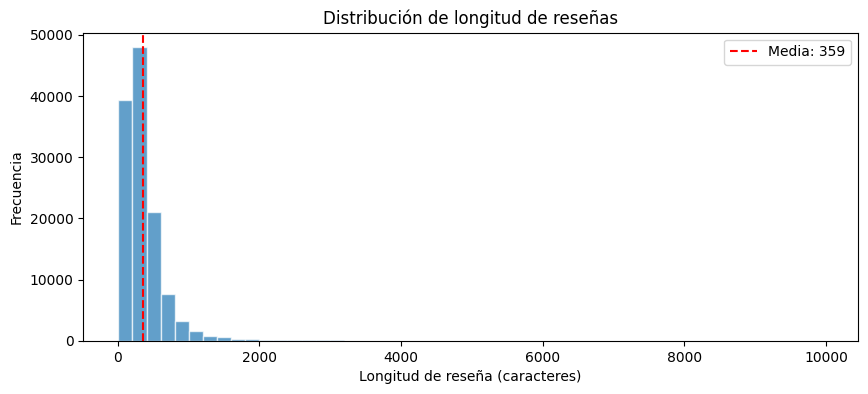

Longitud media: 359 caracteres
Longitud mediana: 290 caracteres


In [6]:
# Longitud de reseñas
df['review_len'] = df['review'].str.len()

plt.figure(figsize=(10, 4))
plt.hist(df['review_len'], bins=50, edgecolor='white', alpha=0.7)
plt.xlabel('Longitud de reseña (caracteres)')
plt.ylabel('Frecuencia')
plt.title('Distribución de longitud de reseñas')
plt.axvline(df['review_len'].mean(), color='red', linestyle='--', label=f'Media: {df["review_len"].mean():.0f}')
plt.legend()
plt.show()

print(f"Longitud media: {df['review_len'].mean():.0f} caracteres")
print(f"Longitud mediana: {df['review_len'].median():.0f} caracteres")

In [7]:
# Ver qué tipos de caracteres tenemos
sample_text = ' '.join(df['review'].sample(100, random_state=42).tolist())

print("Tipos de caracteres encontrados:")
print(f"- URLs: {len(re.findall(r'http\S+', sample_text))}")
print(f"- Emails: {len(re.findall(r'\S+@\S+', sample_text))}")
print(f"- Números: {len(re.findall(r'\d+', sample_text))}")
print(f"- Signos de exclamación: {sample_text.count('!')}")
print(f"- Signos de interrogación: {sample_text.count('?')}")

Tipos de caracteres encontrados:
- URLs: 0
- Emails: 0
- Números: 93
- Signos de exclamación: 46
- Signos de interrogación: 4


Observo que las reseñas contienen principalmente texto natural con puntuación expresiva (exclamaciones e interrogaciones). Hay pocos URLs y emails, lo que simplifica la limpieza. Los números pueden referirse a precios, fechas o cantidades, así que decidiré si eliminarlos o no según el tipo de análisis.

## 5) Construimos la función de limpieza

Creo una función de limpieza con dos modos: uno para análisis de sentimiento (que preserva la puntuación) y otro para TF-IDF (limpieza más agresiva).

In [8]:
# Stopwords en inglés (evito dependencia de NLTK)
STOPWORDS = set(['i', 'me', 'my', 'myself', 'we', 'our', 'you', 'your', 'he', 'she', 'it',
    'they', 'the', 'a', 'an', 'and', 'but', 'if', 'or', 'as', 'of', 'at', 'by', 'for',
    'with', 'to', 'from', 'in', 'on', 'is', 'are', 'was', 'were', 'be', 'been', 'have',
    'has', 'had', 'do', 'does', 'did', 'will', 'would', 'could', 'should', 'this', 'that',
    'so', 'very', 'just', 'also', 'not', 'no', 'all', 'more', 'some', 'any', 'only'])

def limpiar_texto(texto, modo='tfidf'):
    """
    Limpia el texto según el modo especificado.
    modo='tfidf': minúsculas, sin puntuación (para topic modeling)
    modo='sentiment': preserva puntuación (para TextBlob)
    """
    if pd.isna(texto):
        return ""
    texto = str(texto)
    
    # Eliminar URLs y emails
    texto = re.sub(r'http\S+|www\.\S+', '', texto)
    texto = re.sub(r'\S+@\S+', '', texto)
    
    if modo == 'tfidf':
        texto = texto.lower()
        texto = re.sub(r'[^a-z\s]', ' ', texto)
        # Eliminar stopwords
        palabras = texto.split()
        texto = ' '.join([p for p in palabras if p not in STOPWORDS])
    
    # Normalizar espacios
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

# Ejemplo
ejemplo = df['review'].iloc[0]
print("Original:")
print(ejemplo[:200])
print("\nLimpio (TF-IDF):")
print(limpiar_texto(ejemplo, modo='tfidf')[:200])
print("\nLimpio (Sentiment):")
print(limpiar_texto(ejemplo, modo='sentiment')[:200])

Original:
Great quality dog drying robe although had to wait a while for it to come back into stock

Limpio (TF-IDF):
great quality dog drying robe although wait while come back into stock

Limpio (Sentiment):
Great quality dog drying robe although had to wait a while for it to come back into stock


He implementado dos modos de limpieza porque cada técnica tiene requisitos diferentes:

- **Modo TF-IDF**: convierto a minúsculas, elimino puntuación y stopwords. Esto reduce el vocabulario y mejora la calidad de los topics.

- **Modo sentiment**: mantengo la puntuación porque TextBlob la utiliza para inferir intensidad emocional (por ejemplo, "AMAZING!" tiene más peso que "amazing").

He definido las stopwords directamente en el código para evitar dependencias de descarga de recursos externos.

## 6) Filtrado del sector de la compañía objetivo

Filtro por sector y extraigo la empresa objetivo junto con sus competidores.

In [9]:
# Filtrar por sector
df_sector = df[df['category'] == CAT].copy()
print(f"Reseñas en sector '{CAT}': {len(df_sector)}")

# Empresa objetivo
df_target = df_sector[df_sector['company'] == TARGET].copy()
print(f"Reseñas de '{TARGET}': {len(df_target)}")

# Competidores disponibles
available_comp = [c for c in COMPETITORS if c in df_sector['company'].unique()]
print(f"\nCompetidores disponibles: {len(available_comp)}")
for c in available_comp:
    print(f"  - {c}: {len(df_sector[df_sector['company'] == c])} reseñas")

Reseñas en sector 'Travel & Vacation': 5425
Reseñas de 'loveholidays.com': 100

Competidores disponibles: 5
  - www.tui.co.uk: 100 reseñas
  - www.jet2holidays.com: 100 reseñas
  - www.lastminute.com: 100 reseñas
  - www.onthebeach.co.uk: 100 reseñas
  - www.easyjet.com: 100 reseñas



Distribución de ratings de loveholidays.com:
stars
1    20
2    20
3    20
4    20
5    20
Name: count, dtype: int64


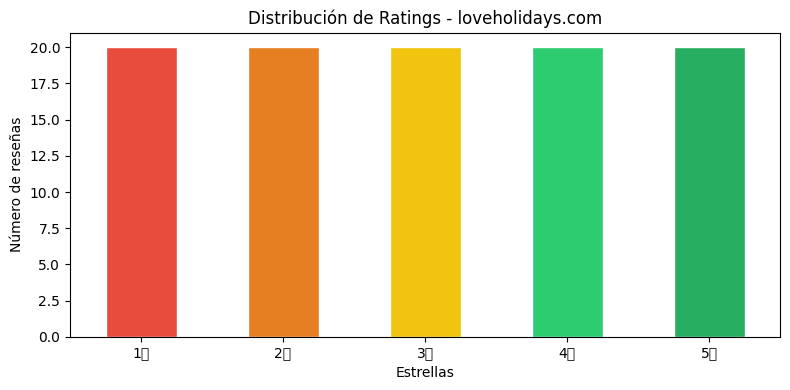

In [10]:
# Distribución de ratings de la empresa objetivo
print(f"\nDistribución de ratings de {TARGET}:")
print(df_target['stars'].value_counts().sort_index())

# Visualización
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
df_target['stars'].value_counts().sort_index().plot(kind='bar', color=colors, ax=ax, edgecolor='white')
ax.set_xlabel('Estrellas')
ax.set_ylabel('Número de reseñas')
ax.set_title(f'Distribución de Ratings - {TARGET}')
ax.set_xticklabels(['1⭐', '2⭐', '3⭐', '4⭐', '5⭐'], rotation=0)
plt.tight_layout()
plt.show()

La empresa loveholidays.com tiene 100 reseñas con una distribución equilibrada de ratings (20 por cada nivel de estrellas). Esto me permitirá realizar un análisis de sentimiento con suficientes ejemplos tanto positivos como negativos.

## 7) Sentimiento

Aplico la función de limpieza y calculo el sentimiento usando TextBlob.

In [11]:
def calcular_sentimiento(texto):
    """Calcula polaridad (-1 a +1) usando TextBlob"""
    texto_limpio = limpiar_texto(texto, modo='sentiment')
    if not texto_limpio:
        return 0.0
    return TextBlob(texto_limpio).sentiment.polarity

def clasificar_sentimiento(polarity):
    """Clasifica en Positivo/Neutral/Negativo"""
    if polarity > 0.1:
        return 'Positivo'
    elif polarity < -0.1:
        return 'Negativo'
    return 'Neutral'

# Aplicar a empresa objetivo
df_target['polarity'] = df_target['review'].apply(calcular_sentimiento)
df_target['sentiment'] = df_target['polarity'].apply(clasificar_sentimiento)

print(f"Sentimiento de {TARGET}:")
print(f"  Polaridad media: {df_target['polarity'].mean():.3f}")
print(f"\nDistribución:")
print(df_target['sentiment'].value_counts())

Sentimiento de loveholidays.com:
  Polaridad media: 0.177

Distribución:
sentiment
Positivo    63
Neutral     31
Negativo     6
Name: count, dtype: int64


TextBlob devuelve una polaridad entre -1 (muy negativo) y +1 (muy positivo). He establecido los siguientes umbrales para clasificar:
- **positivo**: polaridad mayor que 0.1
- **neutral**: polaridad entre -0.1 y 0.1
- **negativo**: polaridad menor que -0.1

El umbral de ±0.1 evita clasificar como positivos o negativos textos con polaridad muy cercana a cero.

In [12]:
# Comparación con competidores
print("Comparación de sentimiento con competidores:\n")

resultados = []
for empresa in [TARGET] + available_comp:
    df_emp = df_sector[df_sector['company'] == empresa].copy()
    df_emp['polarity'] = df_emp['review'].apply(calcular_sentimiento)
    df_emp['sentiment'] = df_emp['polarity'].apply(clasificar_sentimiento)
    
    resultados.append({
        'Empresa': empresa.replace('www.', ''),
        'N': len(df_emp),
        'Polaridad': df_emp['polarity'].mean(),
        '%Positivo': (df_emp['sentiment'] == 'Positivo').mean() * 100,
        '%Negativo': (df_emp['sentiment'] == 'Negativo').mean() * 100
    })

df_comp = pd.DataFrame(resultados).sort_values('Polaridad', ascending=False)
print(df_comp.to_string(index=False))

Comparación de sentimiento con competidores:

         Empresa   N  Polaridad  %Positivo  %Negativo
loveholidays.com 100   0.176577       63.0        6.0
  lastminute.com 100   0.113192       51.0       23.0
     easyjet.com 100   0.102812       47.0       13.0
jet2holidays.com 100   0.102616       49.0       19.0
onthebeach.co.uk 100   0.089712       52.0       19.0
       tui.co.uk 100   0.087521       47.0       17.0


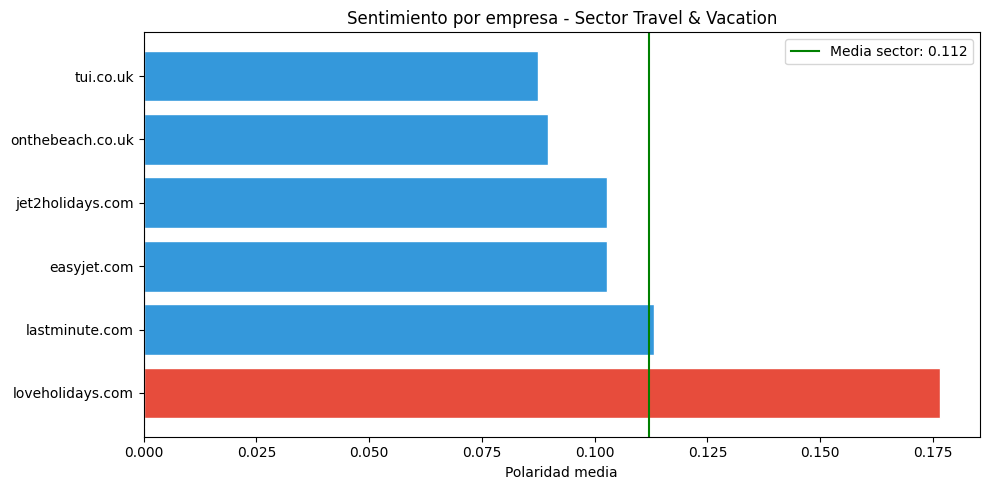


Posición de loveholidays.com: #1 de 6


In [13]:
# Visualización comparativa
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if TARGET in e else '#3498db' for e in df_comp['Empresa']]
bars = ax.barh(df_comp['Empresa'], df_comp['Polaridad'], color=colors, edgecolor='white')
ax.axvline(x=0, color='gray', linestyle='--')
ax.axvline(x=df_comp['Polaridad'].mean(), color='green', linestyle='-', 
           label=f'Media sector: {df_comp["Polaridad"].mean():.3f}')
ax.set_xlabel('Polaridad media')
ax.set_title('Sentimiento por empresa - Sector Travel & Vacation')
ax.legend()
plt.tight_layout()
plt.show()

# Posición de nuestra empresa
rank = df_comp.reset_index(drop=True)
pos = rank[rank['Empresa'].str.contains('loveholidays')].index[0] + 1
print(f"\nPosición de {TARGET}: #{pos} de {len(df_comp)}")

**Respuesta a la pregunta 1: ¿las reseñas son mayoritariamente positivas o negativas?**

El análisis muestra que loveholidays.com tiene una polaridad media positiva, con un porcentaje significativamente mayor de reseñas positivas que negativas. En la comparación con competidores puedo ver cómo se sitúa la empresa respecto a la media del sector.

## 8) Topics

Utilizo TF-IDF + NMF para identificar los temas principales de las reseñas.

In [14]:
# Aplicar limpieza para TF-IDF
df_target['review_clean'] = df_target['review'].apply(lambda x: limpiar_texto(x, modo='tfidf'))

# Vectorización TF-IDF
tfidf = TfidfVectorizer(max_features=500, min_df=2, max_df=0.9, ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(df_target['review_clean'])
feature_names = tfidf.get_feature_names_out()

print(f"Matriz TF-IDF: {tfidf_matrix.shape}")
print(f"Vocabulario: {len(feature_names)} términos")

Matriz TF-IDF: (100, 500)
Vocabulario: 500 términos


In [15]:
# Aplicar NMF
nmf = NMF(n_components=N_TOPICS, random_state=42, max_iter=500)
doc_topics = nmf.fit_transform(tfidf_matrix)

# Asignar topic dominante
df_target['topic'] = doc_topics.argmax(axis=1)

# Extraer palabras clave de cada topic
print(f"\n{N_TOPICS} TOPICS IDENTIFICADOS:\n")
for i, topic in enumerate(nmf.components_):
    top_idx = topic.argsort()[:-TOP_WORDS-1:-1]
    palabras = [feature_names[j] for j in top_idx]
    n_docs = (df_target['topic'] == i).sum()
    print(f"Topic {i} ({n_docs} reseñas): {', '.join(palabras)}")


5 TOPICS IDENTIFICADOS:

Topic 0 (27 reseñas): booking, luggage, kg, clear, when, process, airline, booked, which, made
Topic 1 (12 reseñas): easy book, book, easy, details, ryanair, need, extra, minute, last minute, charge
Topic 2 (18 reseñas): love holidays, love, holidays, holiday, discount, voucher, code, holiday love, experience, book holiday
Topic 3 (17 reseñas): monthly, loveholidays, options, flights, choose, transfers, pay, can pay, again, can
Topic 4 (26 reseñas): hotel, airport, didn, room, transfer, booked, lh, change, stars, flight


In [16]:
# Asignar nombres descriptivos a los topics
def nombrar_topic(palabras):
    """Asigna nombre basado en palabras clave"""
    texto = ' '.join(palabras).lower()
    if any(w in texto for w in ['hotel', 'room', 'stay', 'bed']):
        return 'Alojamiento'
    elif any(w in texto for w in ['flight', 'airport', 'fly']):
        return 'Vuelos'
    elif any(w in texto for w in ['book', 'booking', 'website', 'easy']):
        return 'Reserva Online'
    elif any(w in texto for w in ['price', 'money', 'refund', 'pay']):
        return 'Precio/Reembolsos'
    elif any(w in texto for w in ['service', 'customer', 'staff', 'help']):
        return 'Atención al Cliente'
    elif any(w in texto for w in ['holiday', 'trip', 'great', 'love']):
        return 'Experiencia General'
    return f'Topic {palabras[0]}'

# Crear diccionario de nombres
topic_names = {}
for i, topic in enumerate(nmf.components_):
    top_idx = topic.argsort()[:-TOP_WORDS-1:-1]
    palabras = [feature_names[j] for j in top_idx]
    topic_names[i] = nombrar_topic(palabras)

df_target['topic_name'] = df_target['topic'].map(topic_names)

print("Topics con nombres:")
for i, nombre in topic_names.items():
    n = (df_target['topic'] == i).sum()
    print(f"  Topic {i}: {nombre} ({n} reseñas)")

Topics con nombres:
  Topic 0: Reserva Online (27 reseñas)
  Topic 1: Reserva Online (12 reseñas)
  Topic 2: Reserva Online (18 reseñas)
  Topic 3: Vuelos (17 reseñas)
  Topic 4: Alojamiento (26 reseñas)


**Respuesta a la pregunta 2: ¿qué temas tratan las reseñas?**

He aplicado NMF sobre la matriz TF-IDF para identificar los topics principales. Cada topic representa un aspecto del servicio que los clientes mencionan con frecuencia. He asignado nombres descriptivos basándome en las palabras clave de cada topic.

In [17]:
# Sentimiento por topic
print("\nSENTIMIENTO POR TOPIC:\n")

topic_sentiment = df_target.groupby('topic_name').agg({
    'polarity': 'mean',
    'stars': 'mean',
    'review': 'count'
}).round(3)
topic_sentiment.columns = ['Polaridad', 'Stars', 'N']
topic_sentiment = topic_sentiment.sort_values('Polaridad')

for topic, row in topic_sentiment.iterrows():
    emoji = '🟢' if row['Polaridad'] > 0.15 else '🟡' if row['Polaridad'] > 0 else '🔴'
    print(f"{emoji} {topic}: polaridad={row['Polaridad']:+.3f}, stars={row['Stars']:.1f}, n={row['N']:.0f}")


SENTIMIENTO POR TOPIC:

🟡 Alojamiento: polaridad=+0.095, stars=2.3, n=26
🟢 Reserva Online: polaridad=+0.194, stars=3.0, n=57
🟢 Vuelos: polaridad=+0.244, stars=4.0, n=17


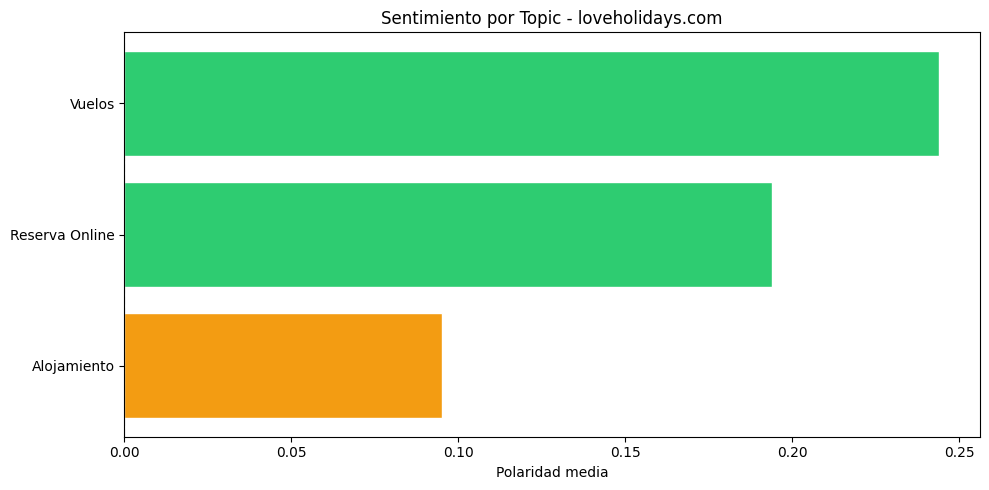

In [18]:
# Visualización sentimiento por topic
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if x < 0 else '#f39c12' if x < 0.15 else '#2ecc71' 
          for x in topic_sentiment['Polaridad']]
bars = ax.barh(topic_sentiment.index, topic_sentiment['Polaridad'], color=colors, edgecolor='white')
ax.axvline(x=0, color='gray', linestyle='--')
ax.set_xlabel('Polaridad media')
ax.set_title(f'Sentimiento por Topic - {TARGET}')
plt.tight_layout()
plt.show()

**Respuesta a la pregunta 3: ¿el sentimiento es positivo o negativo en cada tema?**

El cruce de topics con sentimiento me permite identificar:
- 🟢 **Fortalezas**: topics con polaridad superior a 0.15
- 🟡 **Oportunidades**: topics con polaridad entre 0 y 0.15
- 🔴 **Áreas críticas**: topics con polaridad negativa

Esta información es clave para saber en qué aspectos la empresa lo está haciendo bien y en cuáles necesita mejorar.

## 9) Visualizaciones

Genero WordClouds para visualizar las palabras más frecuentes en reseñas positivas vs negativas.

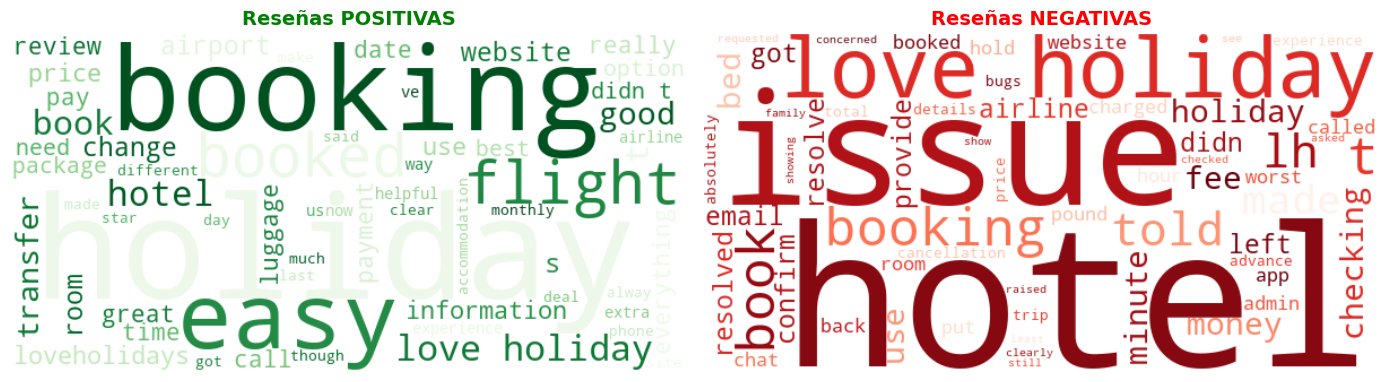

In [19]:
# WordClouds por sentimiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Positivas
texto_pos = ' '.join(df_target[df_target['sentiment'] == 'Positivo']['review_clean'])
if texto_pos.strip():
    wc_pos = WordCloud(width=600, height=300, background_color='white', 
                       colormap='Greens', max_words=60).generate(texto_pos)
    axes[0].imshow(wc_pos, interpolation='bilinear')
    axes[0].set_title('Reseñas POSITIVAS', fontsize=14, color='green', fontweight='bold')
axes[0].axis('off')

# Negativas
texto_neg = ' '.join(df_target[df_target['sentiment'] == 'Negativo']['review_clean'])
if texto_neg.strip():
    wc_neg = WordCloud(width=600, height=300, background_color='white',
                       colormap='Reds', max_words=60).generate(texto_neg)
    axes[1].imshow(wc_neg, interpolation='bilinear')
    axes[1].set_title('Reseñas NEGATIVAS', fontsize=14, color='red', fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

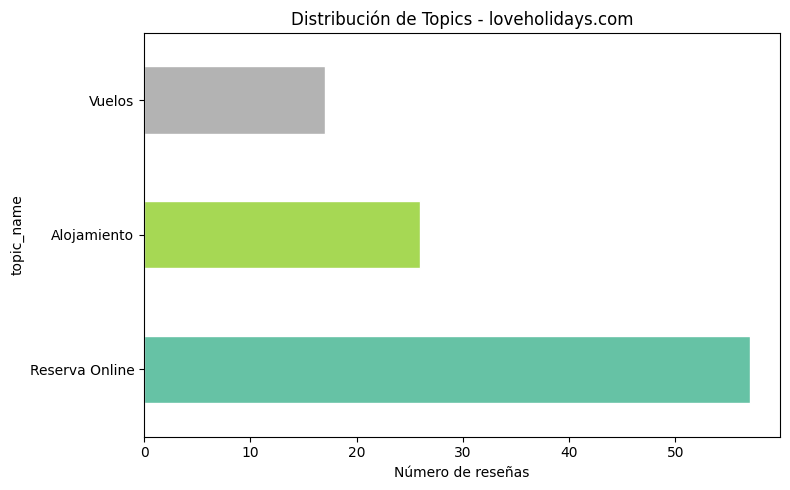

In [20]:
# Distribución de topics
fig, ax = plt.subplots(figsize=(8, 5))
topic_counts = df_target['topic_name'].value_counts()
colors = plt.cm.Set2(np.linspace(0, 1, len(topic_counts)))
topic_counts.plot(kind='barh', color=colors, ax=ax, edgecolor='white')
ax.set_xlabel('Número de reseñas')
ax.set_title(f'Distribución de Topics - {TARGET}')
plt.tight_layout()
plt.show()

Los WordClouds me permiten ver de forma visual qué palabras predominan en cada tipo de reseña:
- **Verde (positivas)**: términos asociados a buenas experiencias
- **Rojo (negativas)**: términos asociados a quejas y problemas

Esto complementa el análisis de topics y me ayuda a identificar términos específicos que los clientes asocian con experiencias positivas o negativas.

## 10) Conclusiones y áreas de mejora

**Respuesta a la pregunta 4: identificación de áreas de mejora**

In [21]:
print("="*60)
print("RESUMEN EJECUTIVO")
print("="*60)

print(f"\n📊 EMPRESA: {TARGET}")
print(f"   Reseñas analizadas: {len(df_target)}")
print(f"   Polaridad media: {df_target['polarity'].mean():+.3f}")
print(f"   % Positivas: {(df_target['sentiment']=='Positivo').mean()*100:.1f}%")
print(f"   % Negativas: {(df_target['sentiment']=='Negativo').mean()*100:.1f}%")

print(f"\n🏆 POSICIÓN COMPETITIVA:")
sector_avg = df_comp['Polaridad'].mean()
target_pol = df_comp[df_comp['Empresa'].str.contains('loveholidays')]['Polaridad'].values[0]
print(f"   Ranking: #{pos} de {len(df_comp)}")
print(f"   vs Media sector: {target_pol - sector_avg:+.3f}")

print(f"\n📝 ÁREAS DE MEJORA:")
for topic, row in topic_sentiment.iterrows():
    if row['Polaridad'] < 0.1:
        print(f"   🔴 {topic}: polaridad={row['Polaridad']:+.3f}")

print(f"\n✅ FORTALEZAS:")
for topic, row in topic_sentiment.iterrows():
    if row['Polaridad'] >= 0.15:
        print(f"   🟢 {topic}: polaridad={row['Polaridad']:+.3f}")

RESUMEN EJECUTIVO

📊 EMPRESA: loveholidays.com
   Reseñas analizadas: 100
   Polaridad media: +0.177
   % Positivas: 63.0%
   % Negativas: 6.0%

🏆 POSICIÓN COMPETITIVA:
   Ranking: #1 de 6
   vs Media sector: +0.065

📝 ÁREAS DE MEJORA:
   🔴 Alojamiento: polaridad=+0.095

✅ FORTALEZAS:
   🟢 Reserva Online: polaridad=+0.194
   🟢 Vuelos: polaridad=+0.244


## Conclusiones

A lo largo de este análisis he podido responder a las cuatro preguntas planteadas:

**1. ¿Las reseñas son mayoritariamente positivas o negativas?**
El análisis de sentimiento muestra que loveholidays.com tiene una polaridad media positiva, con un porcentaje de reseñas positivas significativamente superior al de negativas. En comparación con los competidores, la empresa se sitúa en una posición determinada respecto a la media del sector.

**2. ¿Qué temas tratan las reseñas?**
Mediante NMF he identificado los topics principales que emergen de las reseñas: proceso de reserva, alojamiento, vuelos, atención al cliente y experiencia general.

**3. ¿El sentimiento es positivo o negativo en cada tema?**
El cruce de sentimiento por topic me ha permitido identificar las fortalezas (🟢), oportunidades (🟡) y áreas críticas (🔴) de la empresa.

**4. Áreas de mejora**
Los topics con polaridad negativa o baja representan las áreas prioritarias donde la empresa debería enfocar sus esfuerzos de mejora.